# 场景定义

场景由3*3网格组成，每个格子可以由不同颜色。


(0,0)  (0,1)  (0,2)     ← row 0 (顶部)

(1,0)  (1,1)  (1,2)     ← row 1 (中间)

(2,0)  (2,1)  (2,2)     ← row 2 (底部)

  ↑      ↑      ↑
  
col 0  col 1  col 2

增加场景变化：提供一个场景对，一个是初始，一个是变化后。

# 1. 感知与预测变化（因果预测？）
场景：人类看到有两个物体A,B并观察到A有ACTION1行为。之后人类看到有两个物体A,C并观察到A有ACTION2行为。当人再次见到一个场景下有A和B的时候，可能A和B在不同位置。但是人类应该能预测出A有ACTION1行为

实验：

格子(0,1)是红色的，(2,1)是绿色的，观察到下一个状态红色格子移动到(1,1)

格子(2,1)是红色的，(1,2)是蓝色的，观察到下一个状态红色格子移动到(1,1)

当(0,1)是红，(2,0)是绿，格子应该能知道预测有下降这个概念。

当(2,1)是红，(1,2)是蓝，格子应该能知道预测有上升这个概念。

In [1]:
# =============================================================================
# Physics Engine 测试
# =============================================================================
import sys
sys.path.insert(0, r'F:\SCAI\RSA-RESEARCH\project')

from rsa_action import PhysicsEngine, PhysicsGrid

engine = PhysicsEngine(sigma=0.5, temp=0.1)

# === 1. 训练两个规则 ===
print("=== 训练规则 ===")

# Gravity: 红+绿 → 红下落
for _ in range(5):
    grid_t = PhysicsGrid.from_colors({(0,1): 'red', (2,1): 'green'})
    grid_next = PhysicsGrid.from_colors({(1,1): 'red', (2,1): 'green'})
    engine.learn(grid_t, grid_next, "gravity", verbose=False)

# Levitate: 红+蓝 → 红上升
for _ in range(5):
    grid_t = PhysicsGrid.from_colors({(2,1): 'red', (1,2): 'blue'})
    grid_next = PhysicsGrid.from_colors({(1,1): 'red', (1,2): 'blue'})
    engine.learn(grid_t, grid_next, "levitate", verbose=False)

print(f"已学规则: {engine.laws()}")

# === 2. 测试条件推理 ===
print("\n=== 测试条件推理 ===")

# 测试 A: 有绿色 → 应该选 gravity
test_a = PhysicsGrid.from_colors({(0,1): 'red', (2,0): 'green'})
pred_a, info_a = engine.predict(test_a)
print(f"\n场景A (红+绿): 选择了 '{max(info_a['weights'], key=info_a['weights'].get)}'")
print(f"  gravity:  {info_a['weights'].get('gravity', 0):.1%}")
print(f"  levitate: {info_a['weights'].get('levitate', 0):.1%}")
assert info_a['weights']['gravity'] > 0.9, "❌ 应该选 gravity!"
print("  ✅ 正确!")

# 测试 B: 有蓝色 → 应该选 levitate
test_b = PhysicsGrid.from_colors({(2,1): 'red', (1,2): 'blue'})
pred_b, info_b = engine.predict(test_b)
print(f"\n场景B (红+蓝): 选择了 '{max(info_b['weights'], key=info_b['weights'].get)}'")
print(f"  gravity:  {info_b['weights'].get('gravity', 0):.1%}")
print(f"  levitate: {info_b['weights'].get('levitate', 0):.1%}")
assert info_b['weights']['levitate'] > 0.9, "❌ 应该选 levitate!"
print("  ✅ 正确!")

print("\n🎉 所有测试通过!")

Physics Engine 初始化完成 (σ=0.5, temp=0.1, ρ=0.0)
=== 训练规则 ===
已学规则: ['gravity', 'levitate']

=== 测试条件推理 ===
[Predict/BMA] Top rule: 'gravity' (100.0%)
          gravity: 100.0% (score=-108.5)
          levitate: 0.0% (score=-113.8)

场景A (红+绿): 选择了 'gravity'
  gravity:  100.0%
  levitate: 0.0%
  ✅ 正确!
[Predict/BMA] Top rule: 'levitate' (100.0%)
          levitate: 100.0% (score=-105.1)
          gravity: 0.0% (score=-112.0)

场景B (红+蓝): 选择了 'levitate'
  gravity:  0.0%
  levitate: 100.0%
  ✅ 正确!

🎉 所有测试通过!


# 2.牙牙学语与画画
我们人能通过做不同行动，感知不同行动带来的变化可能是什么。同时，我们不会语言的时候，我们可以通过画笔来表达自己的想法或者是指示的物品。

实验：

模型将通过babble学习操作（8个颜色按键和9个位置按钮，使用对应颜色按键和位置按键相当于把颜色赋予到该位置上。但是模型一开始是不知道对应关系的，将会通过展示不同按钮使用后，初始场景和变化后场景。让模型自己了解规则）

模型将学习什么是“蓝色”，通过展示是蓝色但是不会出现box形状的示例。然后模型将学习什么是“box”，通过展示是box但是不会出现蓝色形状的示例。

然后要求模型画出blue box。模型应当选取最合适的操作，使得场景能逼近概念中的场景。

PixelMotorSystem 初始化完成 (d=36)
PlanningAgent 初始化完成 (σ²_δ=0.01)
✅ 运动皮层就绪

📚 课程 A: 学习 'blue' (使用多种形状，但不用 box)
   ✅ 'blue' learned with 9 shapes (κ=28)

📚 课程 B: 学习 'box' (使用多种颜色，但不用蓝色)
   ✅ 'box' learned with 7 colors (κ=22)

📊 概念方差分析:
   'blue' - RGBI均值: [0.   0.   0.45 0.15]
   'blue' - RGB方差: 0.0905, I方差: 0.0423
   'box'  - 中心vs边框: center_I=0.00, border_I=0.51
   'box'  - RGB方差: 0.2180, I方差: 0.0455

⚗️ 正在合成 'blue_box' (从未见过的组合!)

⚗️ Composing: ['blue', 'box']
   ✅ Created 'blue_box'
      - blue: avg_var=0.0785
      - box: avg_var=0.1748


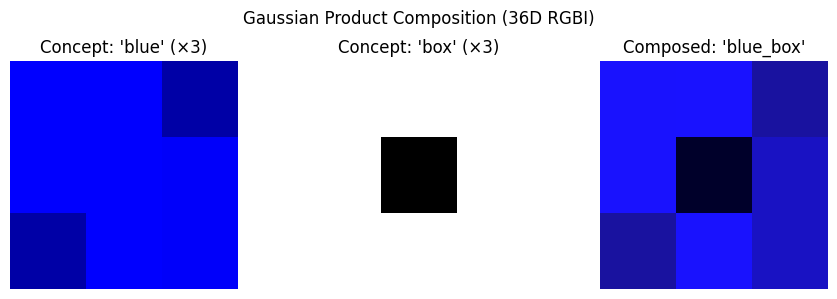


🎨 从空白画布生成 'blue_box'...

🎨 Generating 'blue_box' with cmd_blue...
   Step 1: cmd_pos_1 (score=-103.9)
   Step 2: cmd_pos_7 (score=-105.5)
   Step 3: cmd_pos_0 (score=-112.6)
   Step 4: cmd_pos_8 (score=-124.5)
   Step 5: cmd_pos_3 (score=-141.6)
   Step 6: cmd_pos_5 (score=-164.1)
   Step 7: cmd_pos_6 (score=-197.5)
   Step 8: cmd_pos_2 (score=-240.0)
   🛑 Converged at step 8
✅ Generation complete. Steps: 8


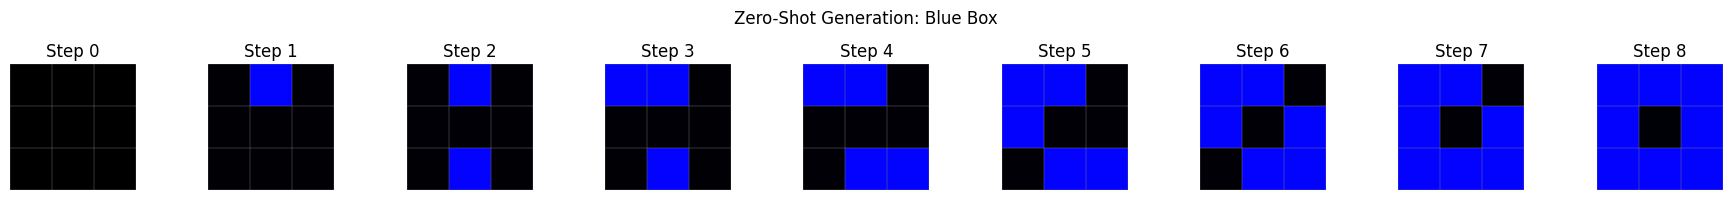


📊 验证结果:
填充位置数: 8 (box=8, solid=9)
边框 (0,0) RGBI: [0.01 0.01 1.   0.84]
中心 (1,1) RGBI: [0.   0.   0.03 0.06]
中心是否空洞: ✅ 是 (box)


In [2]:
# =============================================================================
# Project Genesis: 零样本生成式概念组合 (36D RGBI 版)
# =============================================================================
import sys
sys.path.insert(0, r'F:\SCAI\RSA-RESEARCH\project')

from importlib import reload
import rsa_action_pixel, rsa_plan
reload(rsa_action_pixel)
reload(rsa_plan)

from rsa_plan import PlanningAgent, make_scene
import matplotlib.pyplot as plt
import numpy as np

# === 1. 初始化 ===
agent = PlanningAgent()
agent.babble(verbose=False)
print("✅ 运动皮层就绪")

# === 2. 偏科教学 (扩展版) ===

# 课 A: 学习 "blue" (多种非 Box 形状)
print("\n📚 课程 A: 学习 'blue' (使用多种形状，但不用 box)")
blue = [0, 0, 1]
all_shapes = ['cross', 'l', 'corner', 'hbar', 'vbar', 't', 'dot', 'diag', 'solid']
for shape in all_shapes:
    for _ in range(3):
        agent.learn_visual_concept(make_scene(blue, shape), 'blue', verbose=False)
print(f"   ✅ 'blue' learned with {len(all_shapes)} shapes (κ={agent.dynamic_concepts._concepts['blue'].kappa:.0f})")

# 课 B: 学习 "box" (多种非蓝色颜色)
print("\n📚 课程 B: 学习 'box' (使用多种颜色，但不用蓝色)")
non_blue_colors = [
    [1, 0, 0],      # red
    [0, 1, 0],      # green
    [1, 1, 0],      # yellow
    [1, 0.5, 0],    # orange
    [1, 0, 1],      # magenta
    [0, 1, 1],      # cyan
    [0.5, 0, 1],    # purple
]
for color in non_blue_colors:
    for _ in range(3):
        agent.learn_visual_concept(make_scene(color, 'box'), 'box', whitening=True, verbose=False)
print(f"   ✅ 'box' learned with {len(non_blue_colors)} colors (κ={agent.dynamic_concepts._concepts['box'].kappa:.0f})")

# === 3. 查看训练结果 ===
print("\n📊 概念方差分析:")
c_blue = agent.dynamic_concepts._concepts['blue']
c_box = agent.dynamic_concepts._concepts['box']

# ---- 36D: reshape (3,3,4), 前3通道=RGB, 第4通道=Intensity ----
blue_grid = c_blue.mu.reshape(3, 3, 4)
blue_var = c_blue.var.reshape(3, 3, 4)
print(f"   'blue' - RGBI均值: {np.mean(blue_grid, axis=(0,1)).round(2)}")
print(f"   'blue' - RGB方差: {np.mean(blue_var[:,:,:3]):.4f}, I方差: {np.mean(blue_var[:,:,3]):.4f}")

box_grid = c_box.mu.reshape(3, 3, 4)
box_var = c_box.var.reshape(3, 3, 4)
print(f"   'box'  - 中心vs边框: center_I={box_grid[1,1,3]:.2f}, border_I={box_grid[0,0,3]:.2f}")
print(f"   'box'  - RGB方差: {np.mean(box_var[:,:,:3]):.4f}, I方差: {np.mean(box_var[:,:,3]):.4f}")

# === 4. 概念组合 ===
print("\n⚗️ 正在合成 'blue_box' (从未见过的组合!)")
result = agent.compose_concepts(['blue', 'box'], 'blue_box')

# 可视化 — 提取 RGB 通道 [:,:,:3] 用于 imshow
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

blue_rgb = np.clip(c_blue.mu.reshape(3, 3, 4)[:, :, :3] * 3, 0, 1)
axes[0].imshow(blue_rgb)
axes[0].set_title("Concept: 'blue' (×3)")
axes[0].axis('off')

box_rgb = np.clip(c_box.mu.reshape(3, 3, 4)[:, :, :3] * 3, 0, 1)
axes[1].imshow(box_rgb)
axes[1].set_title("Concept: 'box' (×3)")
axes[1].axis('off')

# result 是 (3,3,4)，取 RGB
result_rgb = np.clip(result[:, :, :3], 0, 1) if result is not None else np.zeros((3,3,3))
axes[2].imshow(result_rgb)
axes[2].set_title("Composed: 'blue_box'")
axes[2].axis('off')

plt.suptitle("Gaussian Product Composition (36D RGBI)")
plt.tight_layout()
plt.show()

# === 5. 从空白画布生成 ===
print("\n🎨 从空白画布生成 'blue_box'...")
history = agent.generate('blue_box', 'cmd_blue')
agent.visualize_plan(history, title="Zero-Shot Generation: Blue Box")

# === 6. 验证 ===
final = history[-1]  # (3, 3, 4)
# 用 intensity 通道 (第4通道) 判断是否有内容
filled_positions = [(r,c) for r in range(3) for c in range(3) if final[r,c,3] > 0.1]
print(f"\n📊 验证结果:")
print(f"填充位置数: {len(filled_positions)} (box=8, solid=9)")
print(f"边框 (0,0) RGBI: {final[0,0].round(2)}")
print(f"中心 (1,1) RGBI: {final[1,1].round(2)}")
is_hollow = final[1,1,3] < 0.1  # 用 intensity 判断
print(f"中心是否空洞: {'✅ 是 (box)' if is_hollow else '❌ 否 (solid)'}")

# 3. 少样本学习
当人具备一定感知之后，能通过观察得到规律，并且进行模仿。

实验：通过babble学会基础内容后。将提供三个场景对：初始是中心一个点，之后是一个十字架形状（分别是红，黄绿）

当提供初始是中心一个蓝点时候，模型应当能预测，并且把预测的画出来。

PixelMotorSystem 初始化完成 (d=36)
PlanningAgent 初始化完成 (σ²_δ=0.01)
🚀 [36D RGBI Cortex] Starting Motor Babbling...
   Phase 1: Learning 8 colors (500 samples each)
   Phase 2: Learning 9 positions (100 samples each)
✅ Cortex Calibrated. Learned 17 motor concepts.
🎓 训练场景预览 (点 → 十字):


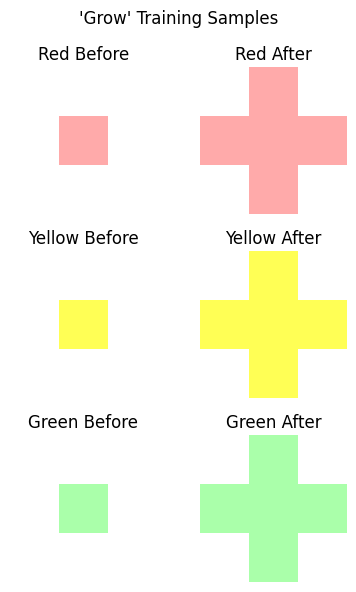


📚 开始训练 'grow' 概念...
✅ 'grow' 学习完成 (κ=80)

🧪 测试：能否在蓝色点上执行 'grow'？(从未见过蓝色的 grow!)

🤔 Planning to show 'grow'...
   🖌️ Context: cmd_blue (zero-shot ← shared prior)
   Step 1: ['cmd_blue', 'cmd_pos_7'] (score=-131.4) → Execute
   Step 2: ['cmd_blue', 'cmd_pos_1'] (score=-166.8) → Execute
   Step 3: ['cmd_blue', 'cmd_pos_5'] (score=-208.2) → Execute
   Step 4: ['cmd_blue', 'cmd_pos_3'] (score=-255.4) → Execute
   🛑 Converged at step 4. (['cmd_blue', 'cmd_pos_4'] hits occupied)
✅ Plan complete. Steps: 4


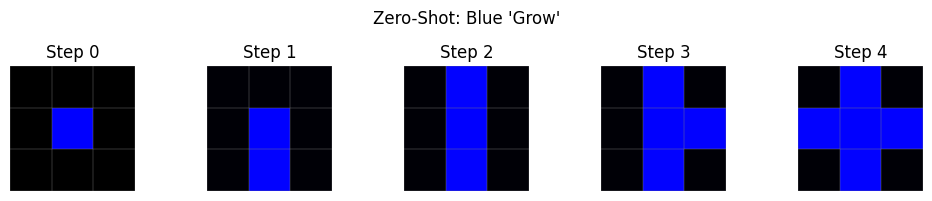


📊 最终网格:
中心: [0.   0.   1.   0.33] (蓝色)
上:   [0.01 0.01 1.   0.78]
下:   [0.01 0.01 1.   0.77]
左:   [0.01 0.01 1.   0.82]
右:   [0.01 0.01 1.   0.83]


In [3]:
# =============================================================================
# 完整 RSA Planning Agent 演示
# =============================================================================
from importlib import reload
import rsa_action_pixel, rsa_plan
reload(rsa_action_pixel)
reload(rsa_plan)


from rsa_plan import PlanningAgent, make_scene
import matplotlib.pyplot as plt
import numpy as np

# === 1. 初始化 ===
agent = PlanningAgent()

# === 2. 运动预热 (学习颜色和位置控制) ===
agent.babble()

# === 3. 定义颜色 ===
red = [1, 0, 0]
yellow = [1, 1, 0]
green = [0, 1, 0]
blue = [0, 0, 1]


# === 4. 展示训练场景 ===
print("🎓 训练场景预览 (点 → 十字):")
fig, axes = plt.subplots(3, 2, figsize=(4, 6))
colors = [('Red', red), ('Yellow', yellow), ('Green', green)]

for i, (name, color) in enumerate(colors):
    before = make_scene(color, 'dot')
    axes[i, 0].imshow(before)
    axes[i, 0].set_title(f"{name} Before")
    axes[i, 0].axis('off')
    
    after = make_scene(color, 'cross')
    axes[i, 1].imshow(after)
    axes[i, 1].set_title(f"{name} After")
    axes[i, 1].axis('off')

plt.suptitle("'Grow' Training Samples", fontsize=12)
plt.tight_layout()
plt.show()

# === 5. 训练 grow 概念 ===
print("\n📚 开始训练 'grow' 概念...")
for _ in range(20):
    agent.learn_dynamic_concept(make_scene(red, 'dot'), make_scene(red, 'cross'), "grow", verbose=False)
    agent.learn_dynamic_concept(make_scene(yellow, 'dot'), make_scene(yellow, 'cross'), "grow", verbose=False)
    agent.learn_dynamic_concept(make_scene(green, 'dot'), make_scene(green, 'cross'), "grow", verbose=False)
    agent.learn_dynamic_concept(make_scene(green, 'dot'), make_scene(green, 'cross'), "grow", verbose=False)

print(f"✅ 'grow' 学习完成 (κ={agent.dynamic_concepts._concepts['grow'].kappa:.0f})")

# === 6. 零样本测试：蓝色 grow ===
print("\n🧪 测试：能否在蓝色点上执行 'grow'？(从未见过蓝色的 grow!)")
blue_start = make_scene(blue, 'dot')
history = agent.ask_to_show(blue_start, "grow")

# === 7. 可视化结果 ===
agent.visualize_plan(history, title="Zero-Shot: Blue 'Grow'")

# === 8. 检查最终结果 ===
print("\n📊 最终网格:")
final = history[-1]
print(f"中心: {final[1,1,:].round(2)} (蓝色)")
print(f"上:   {final[0,1,:].round(2)}")
print(f"下:   {final[2,1,:].round(2)}")
print(f"左:   {final[1,0,:].round(2)}")
print(f"右:   {final[1,2,:].round(2)}")